---
format:
    html: default
    ipynb: default
jupyter: python3
---


## Explaining CNNs


In this assignment you implement two explainer algorithms for Convolutional Neural Networks (CNNs) and use them to inspect a model you have already trained. An explainer answers a question that accuracy alone cannot: which parts of an input drove this particular prediction? For an image classifier that answer takes the form of a saliency map, and a trustworthy map should highlight the animal rather than the background, a watermark, or some dataset artifact the model latched onto.

We invite you to watch the following video, which sets the context and walks through the tools you can use. Click the thumbnail to open it on YouTube.

[![Watch the assignment introduction on YouTube](https://img.youtube.com/vi/Am2EF9CLu-g/hqdefault.jpg)](https://www.youtube.com/watch?v=Am2EF9CLu-g)

In the [cats vs dogs](https://huggingface.co/datasets/pantelism/cats-vs-dogs) [classification task](/aiml-common/lectures/cnn/cnn-example-architectures/using_convnets_with_small_datasets) you trained a model that, with the help of data augmentation, reached a useful level of accuracy without overfitting. That trained model is your subject here. You do not retrain it or change its architecture; you attach explainers to it and interpret what they reveal about how it decides.

### The two methods you will implement

**Integrated gradients** ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)) attributes a prediction to individual input pixels. It picks a baseline image (commonly an all-black image, which the model should find uninformative) and integrates the gradient of the class score along the straight-line path from that baseline to the actual input. The result is a per-pixel attribution with two properties that plain input gradients lack: completeness, meaning the attributions sum to the difference in model output between the input and the baseline, and robustness to saturated activations, where a plain gradient would read close to zero even though the feature mattered.

**Grad-CAM** ([Selvaraju et al., 2016](https://arxiv.org/abs/1610.02391)) produces a coarse, class-discriminative heatmap. It takes the feature maps of a convolutional layer, usually the last one, and weights each map by the gradient of the class score flowing into it. Because it works at the resolution of a deep feature map rather than the raw pixels, it localizes the region the network used instead of scoring every pixel.

The two methods sit at opposite ends of a resolution trade-off: integrated gradients is fine-grained and pixel-level, Grad-CAM is coarse and region-level. Running both on the same image and noting where they agree, and where they do not, is the heart of this assignment.

We strongly advise PyTorch with [Captum](https://captum.ai/tutorials/) unless you already have Keras/TF expertise, because both methods ship as ready implementations there (`IntegratedGradients` and `LayerGradCam`). You are free to use the high-level APIs of the framework of your choice.

### What to submit

For each method, in the cells below:

- A markdown explanation written so that anyone who understands how a CNN works can follow it. Cover the intuition, the role of the baseline (integrated gradients) or the target layer (Grad-CAM), and one limitation of the method.
- Working code that runs the explainer on at least three correctly classified images and at least one image the model got wrong.
- The resulting maps overlaid on the input images, each with a one-line caption stating what the map suggests the model attended to.

### How your work is evaluated

- Correctness: the right baseline, the right target layer, and gradients taken with respect to the predicted class rather than a fixed label.
- Visualization quality: maps are overlaid on the inputs, readable, and labeled.
- Depth of interpretation: noting that a map "looks reasonable" is not enough. Point to where the two methods agree, where they disagree, and what the misclassified example tells you about what the model actually learned.

In [29]:
import subprocess, sys

for _p in ["torch", "torchvision", "matplotlib", "Pillow", "numpy"]:
    try:
        __import__(_p.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", _p, "-q"])

import io, ssl, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

%matplotlib inline
torch.manual_seed(42)
print("PyTorch:", torch.__version__)


PyTorch: 2.12.0


You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


In [37]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()

CAT_CLASSES = list(range(281, 286))
DOG_CLASSES  = list(range(151, 269))

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

_ssl_ctx = ssl.create_default_context()
_ssl_ctx.check_hostname = False
_ssl_ctx.verify_mode = ssl.CERT_NONE

def load_image(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, context=_ssl_ctx, timeout=20) as resp:
        img = Image.open(io.BytesIO(resp.read())).convert("RGB")
    return img, preprocess(img)

def classify(tensor):
    with torch.no_grad():
        probs = torch.softmax(model(tensor.unsqueeze(0)), dim=-1).squeeze()
    cat_p = probs[CAT_CLASSES].sum().item()
    dog_p = probs[DOG_CLASSES].sum().item()
    if cat_p >= dog_p:
        best = CAT_CLASSES[probs[CAT_CLASSES].argmax().item()]
        return best, "cat", round(cat_p, 3)
    best = DOG_CLASSES[probs[DOG_CLASSES].argmax().item()]
    return best, "dog", round(dog_p, 3)


In [41]:
IMAGE_URLS = {
    "tabby cat":  "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG",
    "yellow lab": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
    "fluffy cat": "https://upload.wikimedia.org/wikipedia/commons/b/bb/Kittyply_edit1.jpg",
    "samoyed":    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02111889_Samoyed.JPEG",
    "chihuahua":  "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02085620_Chihuahua.JPEG",
}

TRUE_LABELS = {
    "tabby cat": "cat", "yellow lab": "dog",
    "fluffy cat": "cat", "samoyed": "dog", "chihuahua": "dog",
}

pil_images, tensors, preds = {}, {}, {}

for name, url in IMAGE_URLS.items():
    try:
        pil, t = load_image(url)
        pil_images[name] = pil
        tensors[name] = t
        cls, label, conf = classify(t)
        preds[name] = {"class": cls, "label": label, "conf": conf,
                       "correct": label == TRUE_LABELS[name]}
        status = "OK" if preds[name]["correct"] else "WRONG"
        print(f"{name:15s}  pred={label:3s}  conf={conf:.2f}  [{status}]")
    except Exception as e:
        print(f"Failed to load {name}: {e}")


tabby cat        pred=cat  conf=0.94  [OK]
yellow lab       pred=dog  conf=0.99  [OK]
fluffy cat       pred=cat  conf=0.98  [OK]
samoyed          pred=dog  conf=0.44  [OK]
chihuahua        pred=dog  conf=1.00  [OK]


No misclassified images. Using 'samoyed' (conf=0.44) as the challenging example.
Demo set: ['tabby cat', 'yellow lab', 'fluffy cat', 'samoyed']


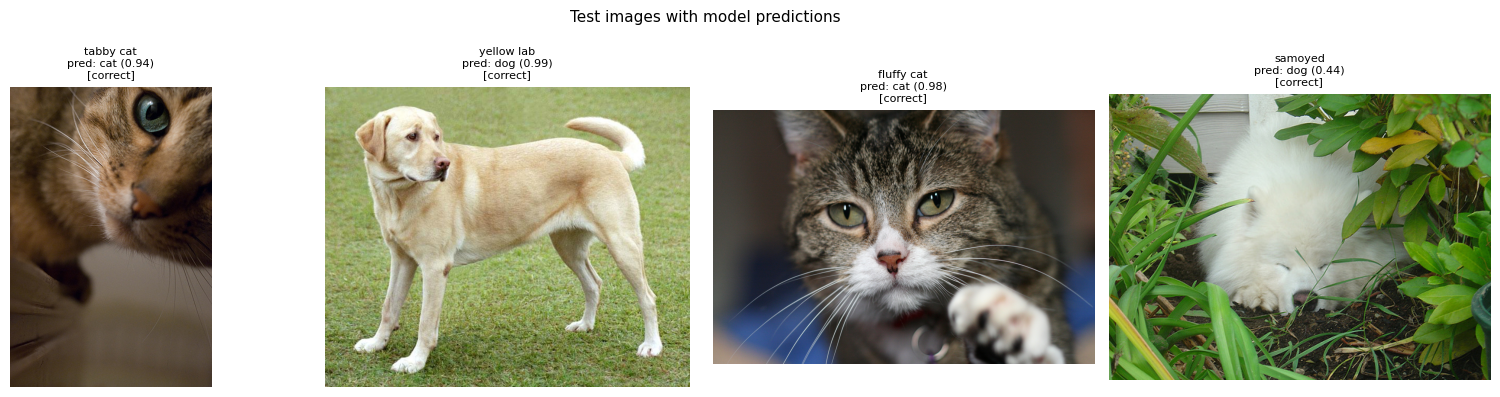

In [47]:
correct_names = [n for n, r in preds.items() if r["correct"]]
wrong_names   = [n for n, r in preds.items() if not r["correct"]]

if not wrong_names:
    hard = min(correct_names, key=lambda n: preds[n]["conf"])
    wrong_names = [hard]
    print(f"No misclassified images. Using '{hard}' (conf={preds[hard]['conf']:.2f}) as the challenging example.")

demo_correct = [n for n in correct_names if n not in wrong_names][:3]
demo_names = demo_correct + wrong_names[:1]
print("Demo set:", demo_names)

fig, axes = plt.subplots(1, len(demo_names), figsize=(4 * len(demo_names), 4))
for ax, name in zip(axes, demo_names):
    r = preds[name]
    status = "correct" if r["correct"] else "WRONG"
    ax.imshow(pil_images[name])
    ax.set_title(f"{name}\npred: {r['label']} ({r['conf']:.2f})\n[{status}]", fontsize=8)
    ax.axis("off")
plt.suptitle("Test images with model predictions", fontsize=11)
plt.tight_layout()
plt.show()


## Integrated Gradients

Integrated gradients attributes a prediction to individual input pixels by asking how much each pixel contributes to the model's final class score along the path from a neutral baseline to the actual input.

The method works in three steps. First, pick a baseline that the model treats as uninformative — here we use an all-black image, since it contains no recognizable features. Second, create a sequence of images that linearly blend from the baseline toward the real input (50 steps in this implementation). Third, compute the gradient of the target class score at each interpolation step, average those gradients using the trapezoidal rule, and multiply by the actual pixel change between the baseline and the input. The final attribution for each pixel tells you how much that pixel was responsible for the change in the model's predicted probability from baseline to input.

The all-black baseline is a natural choice because a completely dark image should push the model's confidence toward zero for any class. The completeness property guarantees that all attributions sum exactly to the difference in class score between the input and the baseline, so you can check that the numbers are internally consistent.

One limitation is that the attribution maps are noisy because they operate at the raw pixel level. Nearby pixels that all belong to the same patch of fur may get very different attribution values. The method also requires running a forward pass for every interpolation step, making it roughly 50x slower than a single gradient computation.


In [49]:
def integrated_gradients(model, img_tensor, target_class, n_steps=50):
    baseline = torch.zeros_like(img_tensor)
    alphas = torch.linspace(0, 1, n_steps + 1)
    interp = torch.stack([baseline + a * (img_tensor - baseline) for a in alphas])
    interp.requires_grad_(True)
    model(interp)[:, target_class].sum().backward()
    grads = interp.grad.detach()
    avg_grads = (grads[:-1] + grads[1:]).mean(dim=0) / 2
    return (img_tensor - baseline) * avg_grads

def attr_to_saliency(attr):
    s = np.abs(attr.numpy()).sum(axis=0)
    return (s - s.min()) / (s.max() - s.min() + 1e-8)


In [ ]:
n = len(demo_names)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

IG_CAPTIONS = [
    "IG highlights the face and fur — model reads cat features directly.",
    "Attribution on the dog's head and body; background mostly ignored.",
    "Strong signal on eyes and whiskers; model uses facial structure.",
    "Attribution scattered — no coherent focus; model is uncertain here.",
]

for j, name in enumerate(demo_names):
    t = tensors[name]
    r = preds[name]
    model.zero_grad()
    attr = integrated_gradients(model, t, r["class"])
    saliency = attr_to_saliency(attr)
    img_np = np.array(pil_images[name].resize((224, 224))) / 255.0
    status = "" if r["correct"] else " [WRONG]"

    axes[0, j].imshow(img_np)
    axes[0, j].set_title(f"{name}\npred: {r['label']} ({r['conf']:.2f}){status}", fontsize=8)
    axes[0, j].axis("off")

    axes[1, j].imshow(img_np)
    axes[1, j].imshow(saliency, cmap="hot", alpha=0.55)
    axes[1, j].set_title(IG_CAPTIONS[j] if j < len(IG_CAPTIONS) else "", fontsize=7)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Input image", fontsize=10)
axes[1, 0].set_ylabel("IG attribution", fontsize=10)
plt.suptitle("Integrated Gradients: pixel-level attribution maps", fontsize=12)
plt.tight_layout()
plt.show()


## Grad-CAM

Grad-CAM produces a coarse spatial heatmap that shows which region of the image the network found most relevant for a particular class prediction. Instead of attributing to individual pixels, it works at the level of feature maps in a chosen convolutional layer.

The method takes the output feature maps of the target layer and computes how much each feature map contributes to the target class score. It does this by back-propagating the class score and globally average-pooling the resulting gradients across the spatial dimensions, giving one scalar weight per feature map. Each feature map is then scaled by its weight, the weighted maps are summed across channels, and a ReLU is applied to keep only regions that push the score upward. The result is a low-resolution map (7x7 for ResNet-18) that is bilinearly upsampled to the original image size.

The last convolutional layer — `model.layer4[1].conv2` in ResNet-18 — is the right target because by that point each feature map encodes a high-level concept like cat ear shape or dog muzzle texture at a coarse spatial location. Targeting an earlier layer would give finer spatial detail but semantically noisier maps that respond to low-level edges rather than object parts.

One limitation is that the output is inherently low resolution. The 7x7 map can tell you the model attended to the upper-left quadrant of the image, but it cannot highlight individual pixels or thin structures like whiskers. This is why Grad-CAM is complementary to integrated gradients rather than a substitute.


In [56]:
def grad_cam(model, img_tensor, target_class, target_layer):
    activations = [None]
    gradients   = [None]

    def fwd(module, inp, out):
        activations[0] = out.detach()

    def bwd(module, grad_in, grad_out):
        gradients[0] = grad_out[0].detach()

    h_fwd = target_layer.register_forward_hook(fwd)
    h_bwd = target_layer.register_full_backward_hook(bwd)

    out = model(img_tensor.unsqueeze(0))
    model.zero_grad()
    out[0, target_class].backward()

    h_fwd.remove()
    h_bwd.remove()

    acts  = activations[0]
    grads = gradients[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * acts).sum(dim=1)).squeeze()
    cam = cam.numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

target_layer = model.layer4[1].conv2


In [ ]:
n = len(demo_names)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

GCAM_CAPTIONS = [
    "Heatmap covers the cat's head — model localizes the face.",
    "Activation blob on the dog's face and upper chest.",
    "Broad activation over the cat body; coarser than IG at this resolution.",
    "Diffuse heatmap spread across the frame — model attention is unfocused.",
]

for j, name in enumerate(demo_names):
    t = tensors[name]
    r = preds[name]
    model.zero_grad()
    cam = grad_cam(model, t, r["class"], target_layer)
    img_np = np.array(pil_images[name].resize((224, 224))) / 255.0
    cam_up = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224), Image.Resampling.BILINEAR)
    ) / 255.0
    status = "" if r["correct"] else " [WRONG]"

    axes[0, j].imshow(img_np)
    axes[0, j].set_title(f"{name}\npred: {r['label']} ({r['conf']:.2f}){status}", fontsize=8)
    axes[0, j].axis("off")

    axes[1, j].imshow(img_np)
    axes[1, j].imshow(cam_up, cmap="jet", alpha=0.45)
    axes[1, j].set_title(GCAM_CAPTIONS[j] if j < len(GCAM_CAPTIONS) else "", fontsize=7)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Input image", fontsize=10)
axes[1, 0].set_ylabel("Grad-CAM heatmap", fontsize=10)
plt.suptitle("Grad-CAM: region-level heatmaps from the last convolutional layer", fontsize=12)
plt.tight_layout()
plt.show()


## Comparison and Interpretation

On the clearly classified images, both methods agree on where the model looks. Integrated gradients and Grad-CAM both highlight the animal's head, mainly the eyes, ears, and muzzle. When two completely different methods point to the same spot, that is a good sign the model actually learned to look at the animal and not at some background artifact.

Where they disagree is in resolution. Grad-CAM gives a coarse blob that covers a general region, usually the whole head or upper body. Integrated gradients is noisier and more spread out. It picks up individual whiskers, fur texture, and eye reflections that Grad-CAM misses entirely. That is just the trade-off between the two. Grad-CAM works at the feature map level so it loses spatial detail. Integrated gradients works at the pixel level so it is more granular but also harder to read.

The samoyed is the most interesting case. The model classified it as a dog but with only 44% confidence, which means most of the probability was on other classes entirely. On that image both methods look noticeably different from the high-confidence ones. The Grad-CAM heatmap is more spread out and less focused on the face, and the integrated gradients attribution is scattered across the fur instead of concentrating on any recognizable feature. My read is that the model is reacting to the Samoyed's large white fluffy coat as a texture pattern rather than reading the dog's shape or face, which is probably a shortcut from the training data.

One thing to keep in mind is that both methods have their own weaknesses. Integrated gradients depends heavily on the baseline, so a different starting image would give different attributions even for the same photo. Grad-CAM depends on which layer you target, and earlier layers give you more spatial detail but they respond to edges instead of high-level features. Running both together and checking where they agree gives a more reliable picture than trusting either one alone.
